In [1]:
from gradcam import calculate_spatial_binning_agreement, min_max_norm, overlay_heatmap

from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [2]:
Drone_MS_2m5 = glob("gradcams/Plecoptera/DroneMS2m5/heatmap_**.png", include_hidden=True, recursive=True)
Satellite_MS_10m = glob("gradcams/Plecoptera/SatelliteMS10m/heatmap_**.png", include_hidden=True, recursive=True)

In [3]:
Drone_MS_2m5 = pd.Series(Drone_MS_2m5).apply(lambda x: os.path.basename(x).split('_conv2d')[0]).values
Satellite_MS_10m = pd.Series(Satellite_MS_10m).apply(lambda x: os.path.basename(x).split('_conv2d')[0]).values

In [4]:
list(set(Drone_MS_2m5) & set(Satellite_MS_10m))

['heatmap_spring_fao_100m_patch_41',
 'heatmap_spring_fao_100m_patch_37',
 'heatmap_spring_fao_100m_patch_47',
 'heatmap_spring_fao_100m_patch_44',
 'heatmap_spring_fao_100m_patch_42',
 'heatmap_spring_fao_100m_patch_38']

In [5]:
list_ = []

for idx in list(set(Drone_MS_2m5) & set(Satellite_MS_10m)):
    
    hm_drone_m_s2m5_0 = plt.imread(f"gradcams/Plecoptera/DroneMS2m5/{idx}_conv2d.png")
    hm_drone_ms_2m5_1 = plt.imread(f"gradcams/Plecoptera/DroneMS2m5/{idx}_conv2d_1.png")
    hm_drone_ms_2m5 = (cv2.resize(min_max_norm(hm_drone_m_s2m5_0), (128, 128), interpolation=cv2.INTER_NEAREST) + cv2.resize(min_max_norm(hm_drone_ms_2m5_1), (128, 128), interpolation=cv2.INTER_NEAREST))/2
     
    hm_satellite_ms_10m_0 = plt.imread(f"gradcams/Plecoptera/SatelliteMS10m/{idx}_conv2d.png")
    hm_satellite_ms_10m_1 = plt.imread(f"gradcams/Plecoptera/SatelliteMS10m/{idx}_conv2d_1.png")
    hm_satellite_ms_10m = (cv2.resize(min_max_norm(hm_satellite_ms_10m_0), (128, 128), interpolation=cv2.INTER_NEAREST) + cv2.resize(min_max_norm(hm_satellite_ms_10m_1), (128, 128), interpolation=cv2.INTER_NEAREST))/2

    list_.append(calculate_spatial_binning_agreement([hm_drone_ms_2m5, hm_satellite_ms_10m], grid_blocks=10, target_shape=(128, 128))['mean_pairwise_correlation'])

In [7]:
print(f'Pairwise spatial agreement correlation as measured by Pearson’s coefficient: {round(np.mean(list_), 2)} (std: {round(np.std(list_), 2)})')

Pairwise spatial agreement correlation as measured by Pearson’s coefficient: 0.68 (std: 0.39)


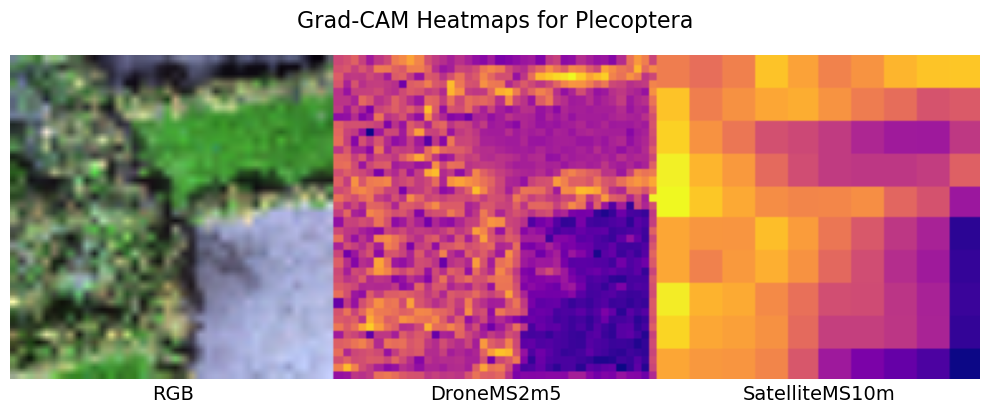

In [8]:
import matplotlib.cm as cm

# Load the RGB image
rgb_img = plt.imread(f"gradcams/plecoptera/DroneMS2m5/{idx.replace('heatmap', 'rgb')}.png")
rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for matplotlib
rgb_img = cv2.resize(rgb_img, (128, 128), interpolation=cv2.INTER_LINEAR) / rgb_img.max()

# Function to apply viridis colormap to single-band heatmaps
def apply_viridis(hm):
    if hm.ndim == 2:  # Single-band
        normalized_hm = (hm - np.min(hm)) / (np.max(hm) - np.min(hm) + 1e-10)  # Normalize to [0, 1]
        return cm.plasma(normalized_hm)[:, :, :3]  # Apply viridis and drop alpha channel
    return hm  # Already RGB

# Convert all heatmaps to RGB using viridis (except the RGB image)
heatmaps_rgb = [
    rgb_img,
    apply_viridis(cv2.resize(hm_drone_ms_2m5, (128, 128), interpolation=cv2.INTER_NEAREST)),
    apply_viridis(cv2.resize(hm_satellite_ms_10m, (128, 128), interpolation=cv2.INTER_NEAREST))
]

# Stack horizontally
stacked = np.hstack(heatmaps_rgb)

# Display
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(stacked)
ax.axis('off')  # Hide axes

# Add title and labels
ax.set_title("Grad-CAM Heatmaps for Plecoptera", fontsize=16, pad=20)

# Labels for each image
labels = ['RGB', 'DroneMS2m5', 'SatelliteMS10m']
x_positions = [128 * (i + 0.5) for i in range(len(labels))]  # Center of each image

for label, x in zip(labels, x_positions):
    ax.text(x, 130, label, ha='center', va='top', fontsize=14, color='black')

plt.tight_layout()
plt.show()